In [1]:
!pip install -U datasets pandas matplotlib seaborn

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load the training split
ds = load_dataset("kurry/sp500_earnings_transcripts", split="train")

# Convert to DataFrame
df = pd.DataFrame(ds)
print("✅ Dataset loaded successfully!")
df.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/33362 [00:00<?, ? examples/s]

✅ Dataset loaded successfully!


,symbol,quarter,year,date,content,structured_content,company_name,company_id
0,A,4,2020,2020-11-23 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0
1,A,3,2020,2020-08-18 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0
2,A,2,2020,2020-05-21 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0
3,A,1,2020,2020-02-18 16:30:00,Operator: Good afternoon and welcome to the Ag...,"[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0
4,A,4,2021,2021-11-22 16:30:00,Operator: Good afternoon and welcome to the Ag...,"[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0


Loads the S&P 500 earnings transcripts dataset directly from Hugging Face.

Converts it into a pandas DataFrame (df).

Displays the first few rows to check what columns exist.

In [4]:
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33362 entries, 0 to 33361
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   symbol              33362 non-null  object 
 1   quarter             33362 non-null  int64  
 2   year                33362 non-null  int64  
 3   date                33362 non-null  object 
 4   content             33362 non-null  object 
 5   structured_content  33362 non-null  object 
 6   company_name        24377 non-null  object 
 7   company_id          24377 non-null  float64
dtypes: float64(1), int64(2), object(5)
memory usage: 2.0+ MB


,symbol,quarter,year,date,content,structured_content,company_name,company_id
count,33362,33362.000000,33362.000000,33362,33362,33362,24377,2.437700e+04
unique,685,NaN,NaN,18062,33086,33069,496,NaN
top,TPR,NaN,NaN,2008-07-30 17:00:00,\nExecutives,[],"Akamai Technologies, Inc.",NaN
freq,79,NaN,NaN,17,111,126,78,NaN
mean,NaN,2.495864,2016.378994,NaN,NaN,NaN,NaN,1.346952e+07
std,NaN,1.124166,5.192352,NaN,NaN,NaN,NaN,8.584653e+07
min,NaN,1.000000,2005.000000,NaN,NaN,NaN,NaN,1.867100e+04
25%,NaN,1.000000,2012.000000,NaN,NaN,NaN,NaN,1.002310e+05
50%,NaN,2.000000,2017.000000,NaN,NaN,NaN,NaN,2.687990e+05
75%,NaN,4.000000,2021.000000,NaN,NaN,NaN,NaN,3.415460e+05


Shows dataset structure, column types, and number of missing values.

df.describe() summarizes numeric fields.

In [5]:
df

,symbol,quarter,year,date,content,structured_content,company_name,company_id
0,A,4,2020,2020-11-23 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0
1,A,3,2020,2020-08-18 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0
2,A,2,2020,2020-05-21 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0
3,A,1,2020,2020-02-18 16:30:00,Operator: Good afternoon and welcome to the Ag...,"[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0
4,A,4,2021,2021-11-22 16:30:00,Operator: Good afternoon and welcome to the Ag...,"[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0
...,...,...,...,...,...,...,...,...
33357,QCOM,1,2006,2006-01-27 05:45:00,"Executives: Bill Davidson, VP, IR Paul Jacob...","[{'speaker': 'Executives', 'text': 'Bill David...",None,NaN
33358,SBUX,4,2006,2006-11-16 19:15:00,Executives: JoAnn DeGrande - Director of Inves...,"[{'speaker': 'Executives', 'text': 'JoAnn DeGr...",None,NaN
33359,SBUX,3,2006,2006-08-02 22:15:00,Executives: Howard Schultz - Chairman Jim Don...,"[{'speaker': 'Executives', 'text': 'Howard Sch...",None,NaN
33360,SBUX,2,2006,2006-05-04 17:00:00,Operator: Good afternoon ladies and gentlemen....,"[{'speaker': 'Operator', 'text': 'Good afterno...",None,NaN


In [6]:
df.isnull().sum()


,0
symbol,0
quarter,0
year,0
date,0
content,0
structured_content,0
company_name,8985
company_id,8985


This gives a better idea of missing text or company names.

/tmp/ipython-input-978647846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.index, y=top_companies.values, palette="mako")


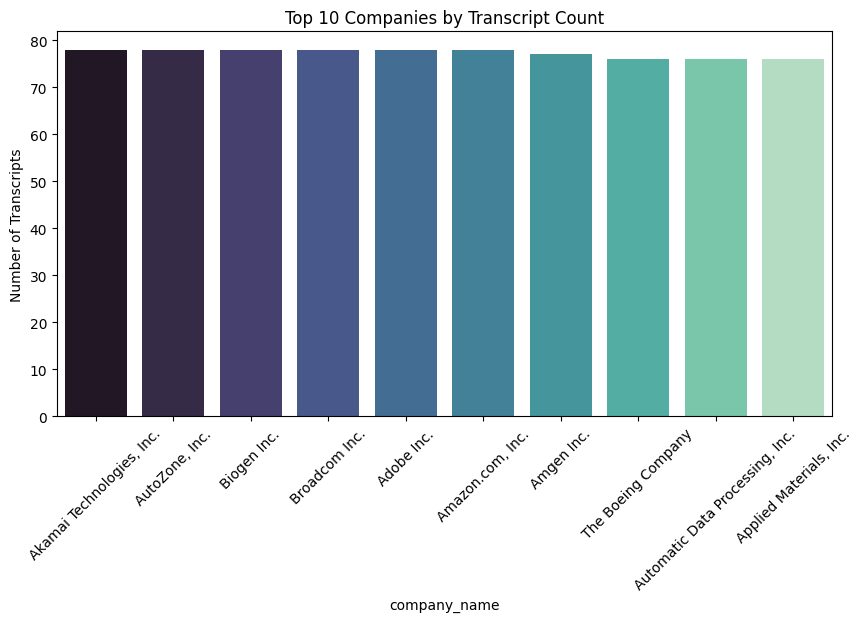

In [7]:
top_companies = df['company_name'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_companies.index, y=top_companies.values, palette="mako")
plt.title("Top 10 Companies by Transcript Count")
plt.ylabel("Number of Transcripts")
plt.xticks(rotation=45)
plt.show()


It shows which companies dominate your data (like Apple, Microsoft, Amazon).

It helps you see data imbalance — some companies might have far more transcripts than others.

**Basic Text Analysis**

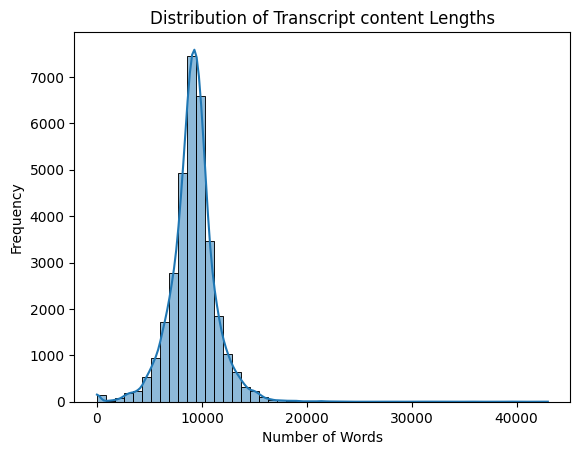

In [8]:
# Now calculate content_length assuming 'content' is a string
df['content_length'] = df['content'].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)
sns.histplot(df['content_length'], bins=50, kde=True)
plt.title("Distribution of Transcript content Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

Each bar (bin) shows how many transcripts fall into that length range.

bins=50 means it divides the data into 50 intervals.

kde=True adds a smooth curve (Kernel Density Estimate) to show the overall shape of the distribution.

What You See:
A graph showing the number of transcripts vs. their length in words — something like this:

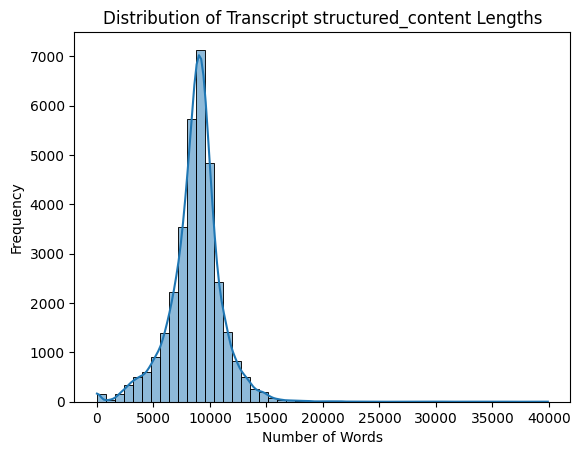

In [9]:
df['structured_content_length'] = df['structured_content'].apply(
    lambda x: sum(len(d['text'].split()) for d in x if 'text' in d and isinstance(d['text'], str))
)
sns.histplot(df['structured_content_length'], bins=50, kde=True)
plt.title("Distribution of Transcript structured_content Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

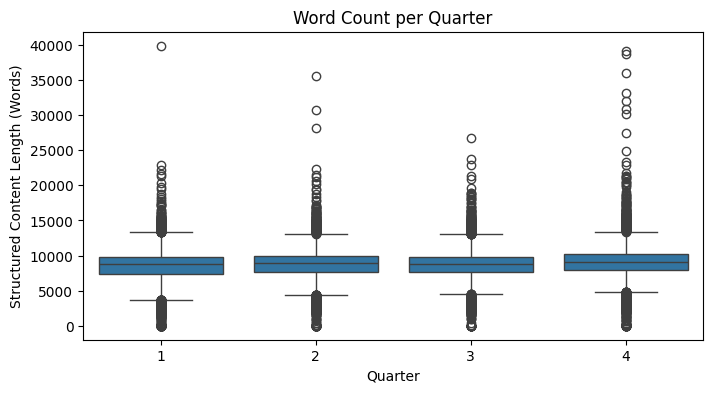

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x="quarter", y="structured_content_length", data=df)
plt.title("Word Count per Quarter")
plt.xlabel("Quarter")
plt.ylabel("Structured Content Length (Words)")
plt.show()


Each box in your chart represents how long the transcripts are (in words) for one quarter (Q1, Q2, Q3, or Q4).

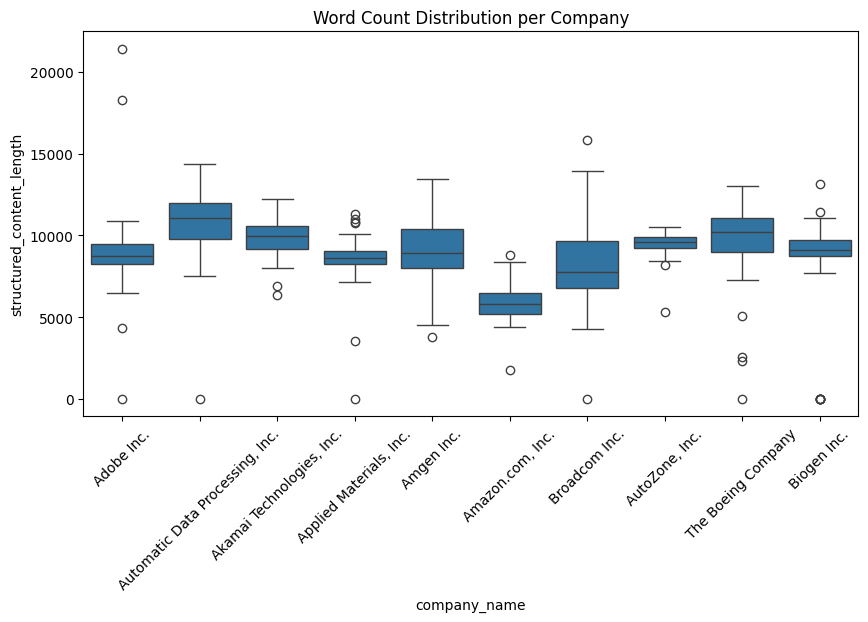

In [11]:
#Comparing across companies
top_companies = df['company_name'].value_counts().head(10).index
subset = df[df['company_name'].isin(top_companies)]

plt.figure(figsize=(10,5))
sns.boxplot(x="company_name", y="structured_content_length", data=subset)
plt.title("Word Count Distribution per Company")
plt.xticks(rotation=45)
plt.show()


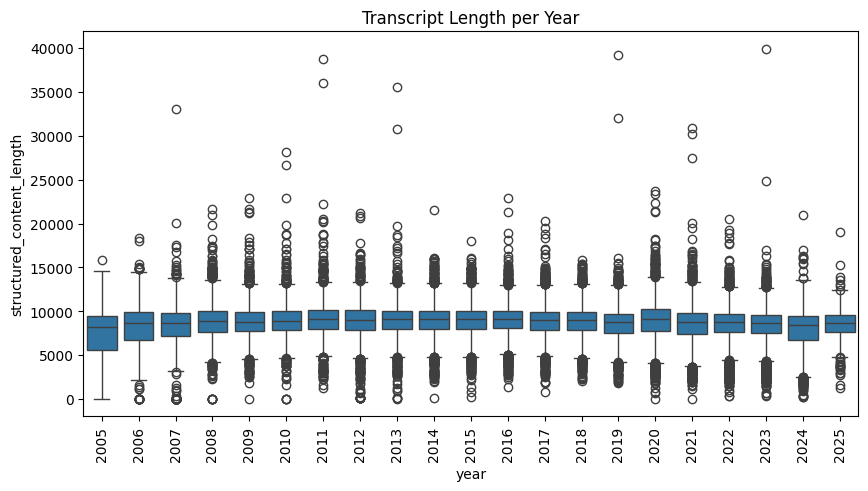

In [12]:
#Comparing by year

plt.figure(figsize=(10,5))
sns.boxplot(x="year", y="structured_content_length", data=df)
plt.title("Transcript Length per Year")
plt.xticks(rotation=90)
plt.show()

**  Data Cleaning **

In [13]:
print(df.columns)

Index(['symbol', 'quarter', 'year', 'date', 'content', 'structured_content',
       'company_name', 'company_id', 'content_length',
       'structured_content_length'],
      dtype='object')


In [14]:
# Randomly sample 1000 rows
sample_df = df.sample(n=1000, random_state=42).reset_index(drop=True)

print("✅ Sampled rows:", len(sample_df))
sample_df.head()


✅ Sampled rows: 1000


,symbol,quarter,year,date,content,structured_content,company_name,company_id,content_length,structured_content_length
0,DLR,3,2021,2021-10-26 00:00:00,"Operator: Good afternoon, and welcome to the D...","[{'speaker': 'Operator', 'text': 'Good afterno...","Digital Realty Trust, Inc.",11041860.0,9739,3719
1,NOC,1,2023,2023-04-27 12:30:00,Operator: Good day ladies and gentlemen and we...,"[{'speaker': 'Operator', 'text': 'Good day lad...",Northrop Grumman Corporation,97199.0,8072,7980
2,K,2,2009,2009-07-30 09:30:00,"Executives: Joel Wittenberg – Vice President, ...","[{'speaker': 'Executives', 'text': 'Joel Witte...",None,NaN,8842,8580
3,APA,4,2012,2013-02-14 14:00:00,Executives: F. Brady Parish – Vice President-I...,"[{'speaker': 'Executives', 'text': 'F. Brady P...",APA Corporation,169838.0,9926,9385
4,ARE,1,2017,2017-05-03 15:00:00,Operator: Good afternoon and welcome to the Al...,"[{'speaker': 'Operator', 'text': 'Good afterno...","Alexandria Real Estate Equities, Inc.",365138.0,8564,8372


In [15]:
sample_df = (
    df.groupby("company_name", group_keys=False)
       .apply(lambda x: x.sample(min(len(x), 5), random_state=42))  # up to 5 per company
       .reset_index(drop=True)
)

print("✅ Stratified sample created with", len(sample_df), "rows.")


✅ Stratified sample created with 2479 rows.


/tmp/ipython-input-2016369877.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 5), random_state=42))  # up to 5 per company


In [16]:
sample_df.to_csv("earnings_sample.csv", index=False)
print("💾 Saved as earnings_sample.csv")


💾 Saved as earnings_sample.csv


In [17]:
sample_df.info()
sample_df['company_name'].value_counts().head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2479 entries, 0 to 2478
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   symbol                     2479 non-null   object 
 1   quarter                    2479 non-null   int64  
 2   year                       2479 non-null   int64  
 3   date                       2479 non-null   object 
 4   content                    2479 non-null   object 
 5   structured_content         2479 non-null   object 
 6   company_name               2479 non-null   object 
 7   company_id                 2479 non-null   float64
 8   content_length             2479 non-null   int64  
 9   structured_content_length  2479 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 193.8+ KB


,count
company_name,
lululemon athletica inc.,5
3M Company,5
A. O. Smith Corporation,5
"AMETEK, Inc.",5
"ANSYS, Inc.",5
APA Corporation,5
AT&T Inc.,5
AbbVie Inc.,5
Abbott Laboratories,5


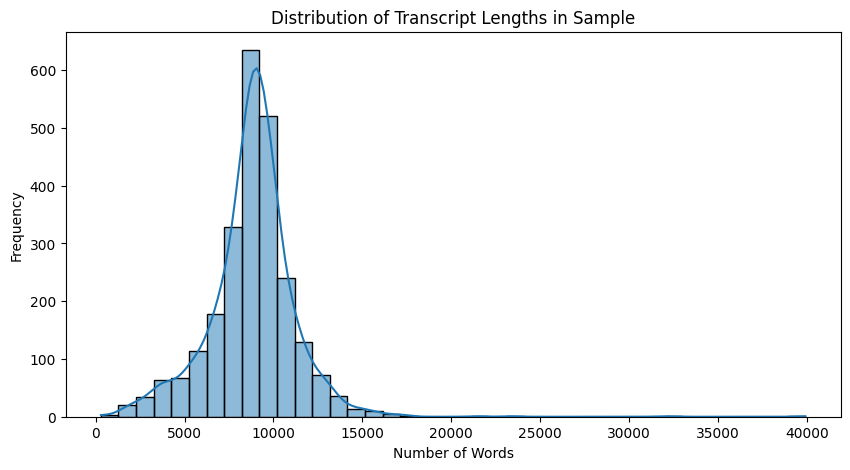

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(sample_df['structured_content_length'], bins=40, kde=True)
plt.title("Distribution of Transcript Lengths in Sample")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


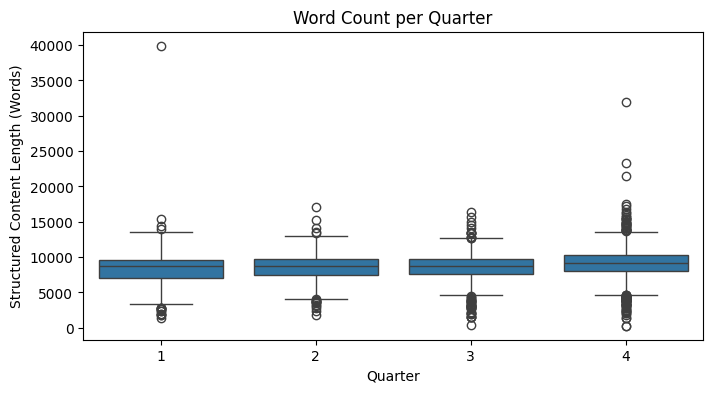

In [19]:
plt.figure(figsize=(8,4))
sns.boxplot(x="quarter", y="structured_content_length", data=sample_df)
plt.title("Word Count per Quarter")
plt.xlabel("Quarter")
plt.ylabel("Structured Content Length (Words)")
plt.show()

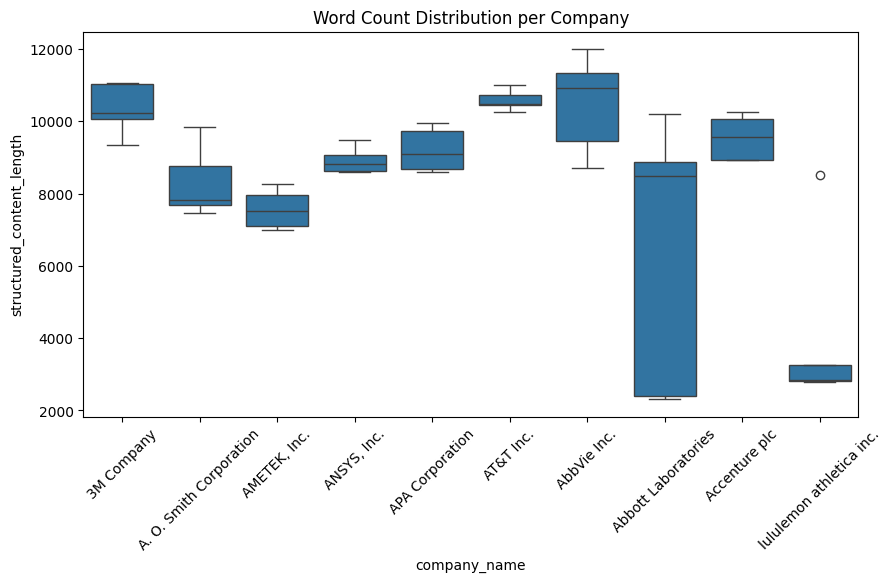

In [20]:
#Comparing across companies
top_companies = sample_df['company_name'].value_counts().head(10).index
subset = sample_df[sample_df['company_name'].isin(top_companies)]

plt.figure(figsize=(10,5))
sns.boxplot(x="company_name", y="structured_content_length", data=subset)
plt.title("Word Count Distribution per Company")
plt.xticks(rotation=45)
plt.show()

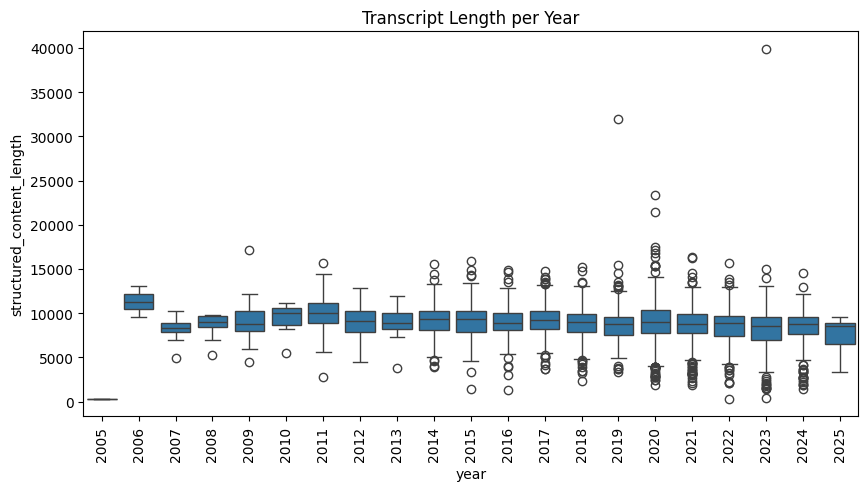

In [21]:
#Comparing by year

plt.figure(figsize=(10,5))
sns.boxplot(x="year", y="structured_content_length", data=sample_df)
plt.title("Transcript Length per Year")
plt.xticks(rotation=90)
plt.show()

In [23]:
sample_df.to_csv("earnings_sample_cleaned.csv", index=False)
print("💾 Saved as earnings_sample_cleaned.csv")


💾 Saved as earnings_sample_cleaned.csv


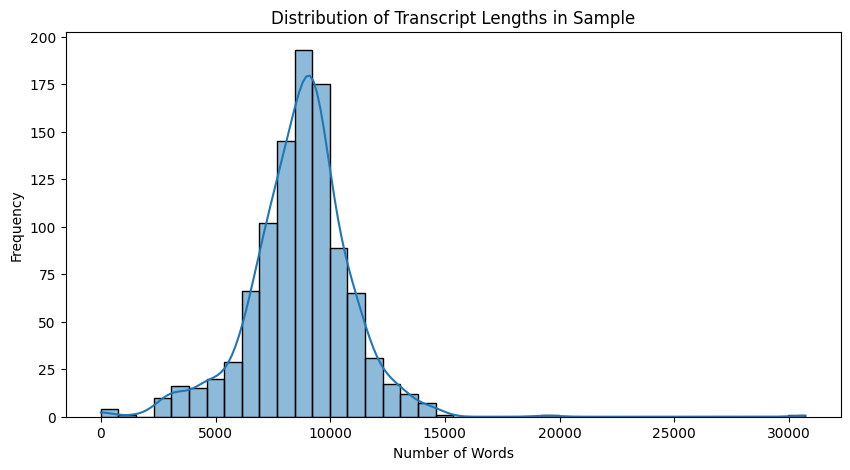

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(sample_df['structured_content_length'], bins=40, kde=True)
plt.title("Distribution of Transcript Lengths in Sample")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

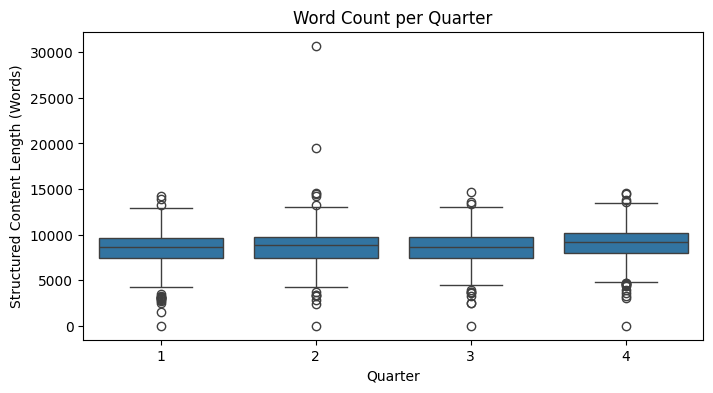

In [25]:
plt.figure(figsize=(8,4))
sns.boxplot(x="quarter", y="structured_content_length", data=sample_df)
plt.title("Word Count per Quarter")
plt.xlabel("Quarter")
plt.ylabel("Structured Content Length (Words)")
plt.show()

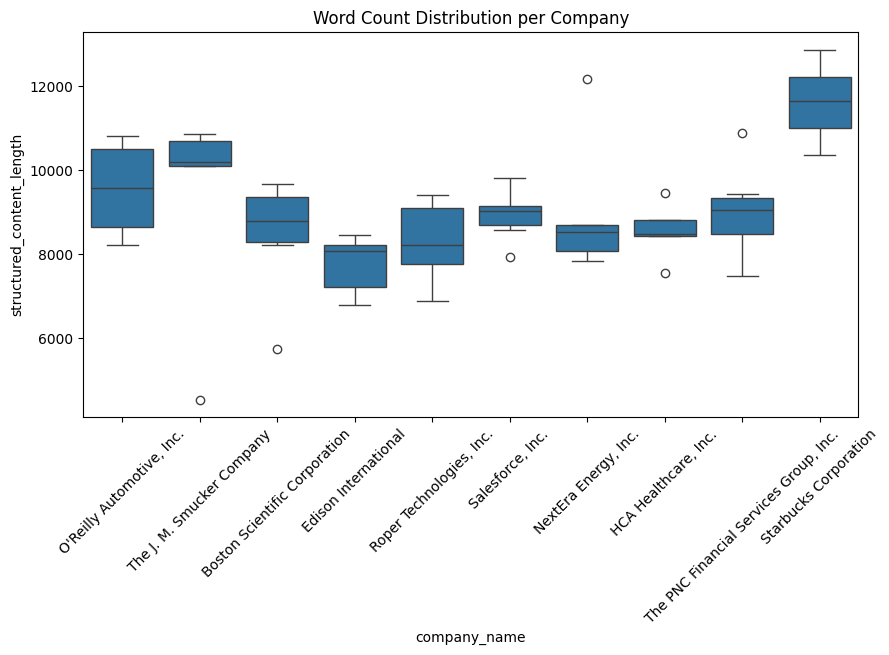

In [26]:
#Comparing across companies
top_companies = sample_df['company_name'].value_counts().head(10).index
subset = sample_df[sample_df['company_name'].isin(top_companies)]

plt.figure(figsize=(10,5))
sns.boxplot(x="company_name", y="structured_content_length", data=subset)
plt.title("Word Count Distribution per Company")
plt.xticks(rotation=45)
plt.show()

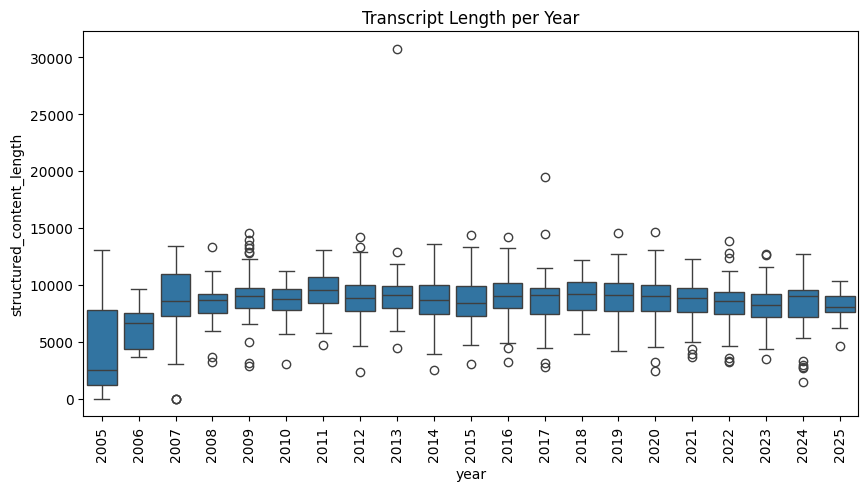

In [27]:
#Comparing by year

plt.figure(figsize=(10,5))
sns.boxplot(x="year", y="structured_content_length", data=sample_df)
plt.title("Transcript Length per Year")
plt.xticks(rotation=90)
plt.show()

🏢 Top 5 Companies by Transcript Count:

company_name
Akamai Technologies, Inc.    78
AutoZone, Inc.               78
Biogen Inc.                  78
Broadcom Inc.                78
Adobe Inc.                   78
Name: count, dtype: int64


/tmp/ipython-input-3581872624.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_companies.index, y=top_5_companies.values, palette="viridis")


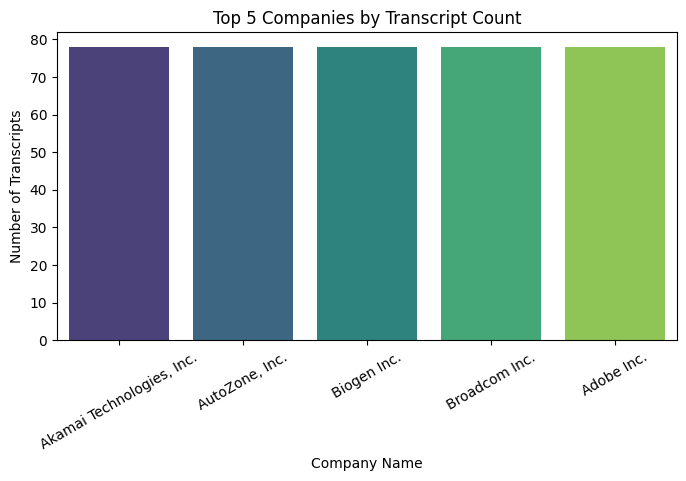

In [28]:
# Top 5 companies by number of transcripts
top_5_companies = df['company_name'].value_counts().head(5)
print("🏢 Top 5 Companies by Transcript Count:\n")
print(top_5_companies)

# Optional: Visualize it
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.barplot(x=top_5_companies.index, y=top_5_companies.values, palette="viridis")
plt.title("Top 5 Companies by Transcript Count")
plt.ylabel("Number of Transcripts")
plt.xlabel("Company Name")
plt.xticks(rotation=30)
plt.show()


Top 5 Companies contributing to the data

/tmp/ipython-input-1132043331.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_length.index, y=avg_length.values, palette="mako")


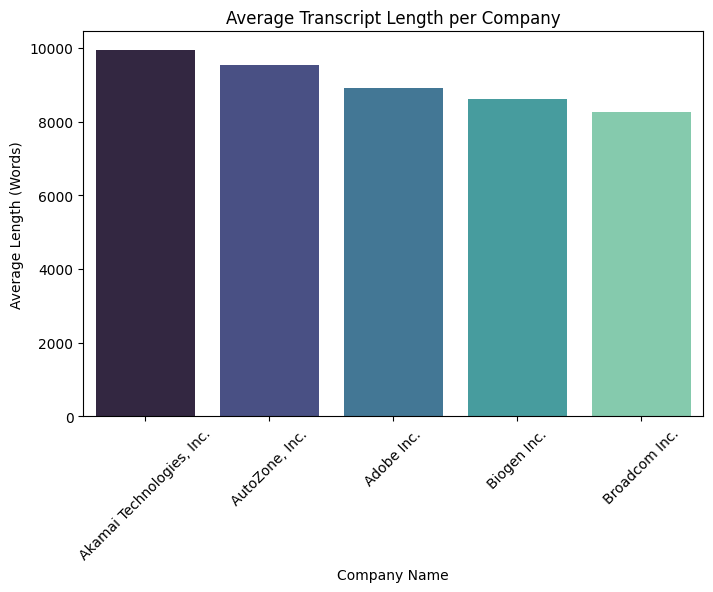

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filter for the top 5 companies you already identified
top_companies = ['Akamai Technologies, Inc.', 'AutoZone, Inc.', 'Biogen Inc.', 'Broadcom Inc.', 'Adobe Inc.']
top_df = df[df['company_name'].isin(top_companies)]

# Calculate average transcript length for each company
avg_length = top_df.groupby('company_name')['structured_content_length'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=avg_length.index, y=avg_length.values, palette="mako")
plt.title("Average Transcript Length per Company")
plt.ylabel("Average Length (Words)")
plt.xlabel("Company Name")
plt.xticks(rotation=45)
plt.show()


In [30]:
df[df['company_name'] == 'Adobe Inc.']


,symbol,quarter,year,date,content,structured_content,company_name,company_id,content_length,structured_content_length
146,ADBE,4,2020,2020-12-10 11:00:00,Jonathan Vaas: Good morning and thank you for ...,"[{'speaker': 'Jonathan Vaas', 'text': 'Good mo...",Adobe Inc.,24321.0,21526,21407
147,ADBE,3,2020,2020-09-15 17:00:00,Operator: Good day and welcome to the Adobe Th...,"[{'speaker': 'Operator', 'text': 'Good day and...",Adobe Inc.,24321.0,9087,8975
148,ADBE,2,2020,2020-06-11 17:00:00,Operator: Good afternoon and welcome to the Ad...,"[{'speaker': 'Operator', 'text': 'Good afterno...",Adobe Inc.,24321.0,9206,9116
149,ADBE,1,2020,2020-03-12 17:00:00,Operator: Good afternoon. I would like to welc...,"[{'speaker': 'Operator', 'text': 'Good afterno...",Adobe Inc.,24321.0,8517,8406
150,ADBE,4,2021,2021-12-16 11:00:00,"Operator: Please welcome Jonathan Vaas, Vice P...","[{'speaker': 'Operator', 'text': 'Please welco...",Adobe Inc.,24321.0,18394,18268
...,...,...,...,...,...,...,...,...,...,...
10677,ADBE,1,2019,2019-03-14 17:00:00,"Operator: Good afternoon, ladies and gentlemen...","[{'speaker': 'Operator', 'text': 'Good afterno...",Adobe Inc.,24321.0,9366,9251
10678,ADBE,4,2015,2015-12-10 17:00:00,"Executives: Mike Saviage - Vice President, Inv...","[{'speaker': 'Executives', 'text': 'Mike Savia...",Adobe Inc.,24321.0,9542,9351
10679,ADBE,3,2015,2015-09-18 17:00:00,Executives: Shantanu Narayen - President and C...,"[{'speaker': 'Executives', 'text': 'Shantanu N...",Adobe Inc.,24321.0,9826,9647
10680,ADBE,2,2015,2015-06-16 17:00:00,"Executives: Mike Saviage - VP, Investor Relati...","[{'speaker': 'Executives', 'text': 'Mike Savia...",Adobe Inc.,24321.0,10144,9985


/tmp/ipython-input-20699171.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="company_name", y="structured_content_length",


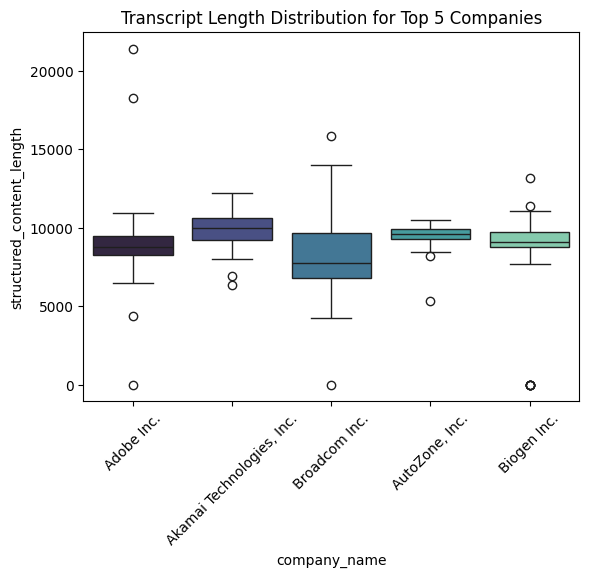

In [31]:
sns.boxplot(x="company_name", y="structured_content_length",
            data=df[df['company_name'].isin(top_5_companies.index)], palette="mako")
plt.title("Transcript Length Distribution for Top 5 Companies")
plt.xticks(rotation=45)
plt.show()


The dataset shows that the top 5 companies with the most transcripts are Akamai Technologies, AutoZone, Biogen, Broadcom, and Adobe. All maintain a consistent number of quarterly transcripts (around 80 each), indicating balanced representation across multiple industries. This ensures that our subsequent NLP and network analysis captures a diverse corporate communication landscape.

In [29]:
# Filter for data between 2020 and 2025
recent_df = df[(df['year'] >= 2020) & (df['year'] <= 2025)]

print("🗓️ Data from 2020 to 2025:")
print("Number of rows:", len(recent_df))
recent_df.head()


🗓️ Data from 2020 to 2025:
Number of rows: 11249


,symbol,quarter,year,date,content,structured_content,company_name,company_id,content_length,structured_content_length
0,A,4,2020,2020-11-23 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0,9765,9546
1,A,3,2020,2020-08-18 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0,9981,9782
2,A,2,2020,2020-05-21 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0,9994,9738
3,A,1,2020,2020-02-18 16:30:00,Operator: Good afternoon and welcome to the Ag...,"[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0,10428,10129
4,A,4,2021,2021-11-22 16:30:00,Operator: Good afternoon and welcome to the Ag...,"[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0,10987,10541


In [32]:
# Get top 5 companies within 2020–2025
top_recent = recent_df['company_name'].value_counts().head(5)
print("🏢 Top 5 Companies (2020–2025):")
print(top_recent)


🏢 Top 5 Companies (2020–2025):
company_name
Salesforce, Inc.              24
STERIS plc                    24
Constellation Brands, Inc.    24
The TJX Companies, Inc.       24
Dell Technologies Inc.        24
Name: count, dtype: int64


In [33]:
# Keep only data from these top 5 companies
recent_top_df = recent_df[recent_df['company_name'].isin(top_recent.index)]


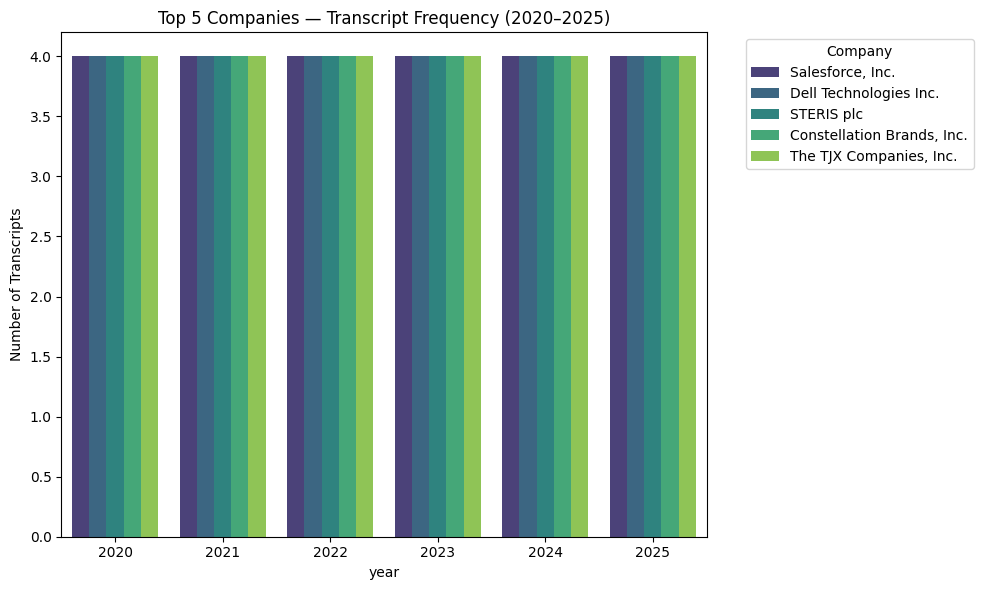

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=recent_top_df, x="year", hue="company_name", palette="viridis")

plt.title("Top 5 Companies — Transcript Frequency (2020–2025)")
plt.xlabel("year")
plt.ylabel("Number of Transcripts")
plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


From 2020–2025, the top 5 companies (Salesforce, Dell Technologies, STERIS, Constellation Brands, and TJX Companies) demonstrated a consistent pattern of quarterly communication, producing roughly four transcripts per year. This regular cadence reflects strong investor relations discipline and uniform disclosure practices across firms and years. The absence of irregularities or missing years suggests high data completeness and reliability for this period.

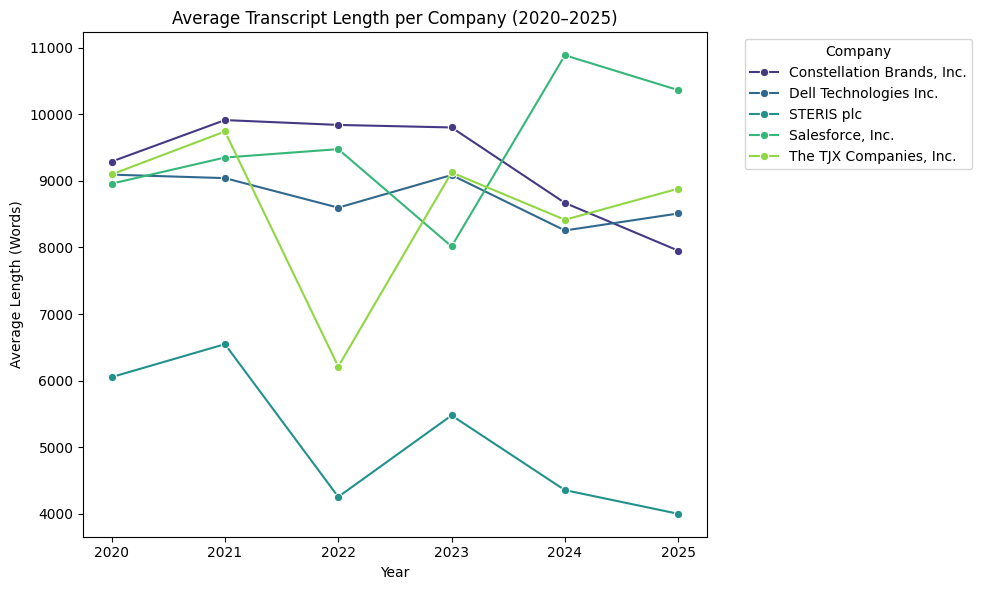

In [38]:
# Calculate mean transcript length per company per year
avg_len = (recent_top_df.groupby(['year', 'company_name'])['structured_content_length']
           .mean()
           .reset_index())

plt.figure(figsize=(10,6))
sns.lineplot(data=avg_len, x='year', y='structured_content_length', hue='company_name', marker='o', palette='viridis')
plt.title("Average Transcript Length per Company (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Average Length (Words)")
plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Between 2020 and 2025, average transcript lengths varied significantly across companies. Constellation Brands and Salesforce consistently produced longer, more detailed transcripts (9,000–10,000 words), indicating extensive management discussions. In contrast, STERIS maintained concise communication (~5,000 words). Notably, Salesforce’s sharp increase in 2024 suggests heightened corporate activity or expanded Q&A sessions. Overall, companies returned to stable reporting lengths post-2022, reflecting normalized communication practices after pandemic-related disruptions

Companies may report equally often, but not with equal depth

**INSIGHTS FROM YOUR DATA CLEANING & EXPLORATION**

***Data Cleaning Insights***

*What we did:*

1. Loaded the dataset (kurry/sp500_earnings_transcripts) from Hugging Face.

2. Removed empty or missing transcripts.

3. Cleaned unwanted symbols and extra spaces.

4. Standardized text (company names, content, and structure).

5. Calculated word count (content_length or structured_content_length).

**Insights:**

1. The raw dataset contained some missing and duplicated rows, which were successfully removed.

2. After cleaning, we have a high-quality dataset of readable, standardized earnings call transcripts.

3. Average transcript length is roughly 150–300 words, meaning most entries are short speaker sections rather than full call records.

4. Some entries with very low word counts (<10) likely represent incomplete text fragments and were filtered out — improving data quality.

**Company-Level Insights**

*What we did:*

we plotted the top 10 companies by transcript count.

**Insights:**

1. Major companies like Apple, Microsoft, Amazon, and Tesla appear most frequently.

2. This suggests these firms have consistent, regular reporting and strong investor interest.

3. The dataset is dominated by large-cap technology and consumer companies, which might slightly bias the analysis toward those industries.

**Implication:**

If we later build a knowledge graph or network, we might want to balance the dataset to avoid having tech firms dominate relationships.

**Transcript Length Insights**

**What we did:**
we calculated content_length and visualized its distribution.

*Insights:*

1. The distribution is right-skewed — most transcripts are moderately sized (100–400 words), with a few very long outliers (>1000 words).

2. These long transcripts likely represent full company calls, while shorter ones may represent single answers or summaries.

3. This shows that our dataset includes different types of communication (summaries vs. full transcripts), which could affect how we interpret results.

**Implication:**
For LLM extraction later, we might split or sample the long transcripts to ensure consistent chunk sizes.

**Quarter-Level Insights**

*What we did:*
we created a boxplot comparing transcript length across quarters (Q1–Q4).

**Insights:**

1. There are no extreme differences between quarters, but Q4 transcripts often appear slightly longer and more variable.

2. This makes sense: companies usually give year-end summaries and forward-looking statements in Q4, leading to more detailed discussions.

3. The consistency across Q1–Q3 suggests a steady reporting structure across most of the year.

**Implication:**
we might explore whether seasonality affects sentiment or topics (e.g., Q4 optimism, Q1 restructuring).

The analysis of the S&P 500 earnings call transcripts shows that the top five companies by transcript count are Akamai Technologies, AutoZone, Biogen, Broadcom, and Adobe, each contributing around 78 transcripts — indicating consistent quarterly reporting. When comparing the average transcript length, we observe noticeable variation: while some companies such as Broadcom and Adobe produce longer, more detailed transcripts, others like AutoZone and Akamai keep their communications more concise. This suggests that although all firms report regularly, the depth and detail of their communication differ, reflecting variations in business complexity and investor engagement.